In [10]:
import pandas as pd
data=pd.read_csv("data.csv",index_col=0)
data.index=pd.to_datetime(data.index)
data.columns = ['Energy Production']


In [11]:
values=data['Energy Production']
data=pd.concat([values,values.shift(1)],1)
data.columns=['Energy Production','forecast']
data=data.iloc[1:984,:]
data

,Energy Production,forecast
DATE,,
1939-02-01,3.4100,3.3842
1939-03-01,3.4875,3.4100
1939-04-01,3.5133,3.4875
1939-05-01,3.5133,3.5133
1939-06-01,3.5650,3.5133
...,...,...
2020-08-01,111.0092,114.7288
2020-09-01,97.0955,111.0092
2020-10-01,92.1078,97.0955


In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error as mse
train = data.loc['1985-01-01':'2016-12-01']
test = data.loc['2017-01-01':]

mse(data['Energy Production'],data['forecast'])

31.406203938290947

In [13]:
from statsmodels.tsa.stattools import adfuller

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )

    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data is stationary")
    else:
        print("weak evidence against null hypothesis,indicating it is non-stationary ")

adfuller_test(data['Energy Production'])

ADF Test Statistic : -0.7484402785549122
p-value : 0.8338004157710255
#Lags Used : 22
Number of Observations : 960
weak evidence against null hypothesis,indicating it is non-stationary 


In [14]:
data['Sales First Difference'] = data['Energy Production'] - data['Energy Production'].shift(1)
data['Seasonal First Difference']=data['Energy Production']-data['Energy Production'].shift(12)
data.head(13)

,Energy Production,forecast,Sales First Difference,Seasonal First Difference
DATE,,,,
1939-02-01,3.4100,3.3842,NaN,NaN
1939-03-01,3.4875,3.4100,0.0775,NaN
1939-04-01,3.5133,3.4875,0.0258,NaN
1939-05-01,3.5133,3.5133,0.0000,NaN
1939-06-01,3.5650,3.5133,0.0517,NaN
1939-07-01,3.5650,3.5650,0.0000,NaN
1939-08-01,3.6167,3.5650,0.0517,NaN
1939-09-01,3.7200,3.6167,0.1033,NaN
1939-10-01,3.7200,3.7200,0.0000,NaN


In [15]:
adfuller_test(data['Seasonal First Difference'].dropna())

ADF Test Statistic : -6.664115953894872
p-value : 4.76521533509656e-09
#Lags Used : 22
Number of Observations : 948
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data is stationary


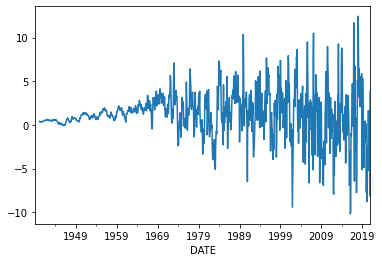

In [16]:
data['Seasonal First Difference'].plot()

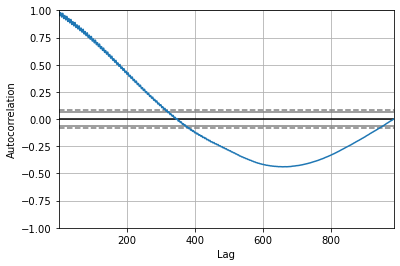

In [17]:
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
autocorrelation_plot(data['Energy Production'])
plt.show()

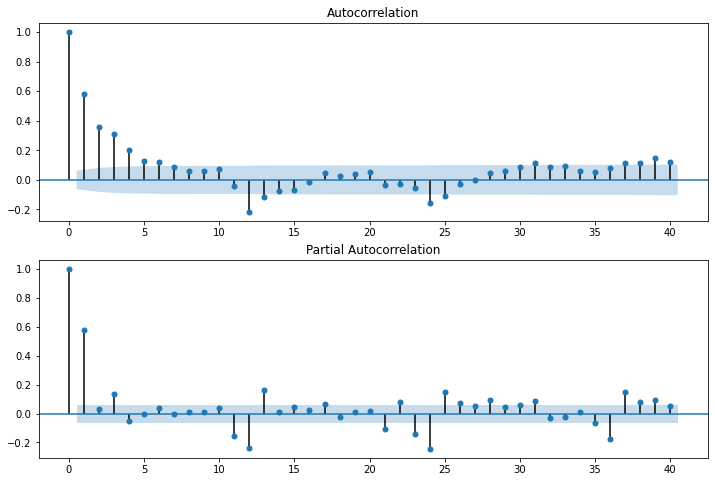

In [18]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(data['Seasonal First Difference'].dropna(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(data['Seasonal First Difference'].dropna(),lags=40,ax=ax2)

In [20]:
from statsmodels.tsa.arima_model import ARIMA

data=pd.read_csv("data.csv",index_col=0)
data.index=pd.to_datetime(data.index)
data.columns = ['Energy Production']

train = data['1985-01-01':'2016-12-01']
test = data['2017-01-01':]

model=ARIMA(train,order=(6,1,3))  

model_fit=model.fit()
model_fit.summary()

C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\base\tsa_model.py:162: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  % freq, ValueWarning)
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\base\tsa_model.py:162: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  % freq, ValueWarning)
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\base\model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\base\model.py:568: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                              ARIMA Model Results                              
===============================================================================
Dep. Variable:     D.Energy Production   No. Observations:                  383
Model:                  ARIMA(6, 1, 3)   Log Likelihood               -1002.235
Method:                        css-mle   S.D. of innovations                nan
Date:                 Sat, 27 Feb 2021   AIC                           2026.471
Time:                         20:54:53   BIC                           2069.899
Sample:                     02-01-1985   HQIC                          2043.698
                          - 12-01-2016                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         0.0628        nan        nan        nan         nan         nan
ar.L1.D.Energy Production    -0.1451   1.09e-06  -1.33e+05      0.000      -0.145      -0.145
ar.L2.D.Energy Production    -0.1932   1.38e-06   -1.4e+05      0.000      -0.193      -0.193
ar.L3.D.Energy Production    -0.9081   3.57e-06  -2.54e+05      0.000      -0.908      -0.908
ar.L4.D.Energy Production    -0.1718   1.18e-06  -1.46e+05      0.000      -0.172      -0.172
ar.L5.D.Energy Production    -0.1651        nan        nan        nan         nan         nan
ar.L6.D.Energy Production     0.0648        nan        nan        nan         nan         nan
ma.L1.D.Energy Production    -0.0119      0.032     -0.372      0.710      -0.075       0.051
ma.L2.D.Energy Production    -0.0048      0.027     -0.180      0.857      -0.057       0.048
ma.L3.D.Energy Production     0.8707      0.029     29.684      0.000       0.813       0.928
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1           -1.0262           -0.0000j            1.0262           -0.5000
AR.2            0.4997           -0.8662j            1.0000           -0.1667
AR.3            0.4997           +0.8662j            1.0000            0.1667
AR.4           -0.7604           -1.7588j            1.9162           -0.3149
AR.5           -0.7604           +1.7588j            1.9162            0.3149
AR.6            4.0948           -0.0000j            4.0948           -0.0000
MA.1            0.5277           -0.9032j            1.0460           -0.1658
MA.2            0.5277           +0.9032j            1.0460            0.1658
MA.3           -1.0498           -0.0000j            1.0498           -0.5000
-----------------------------------------------------------------------------
"""

In [24]:
train = data['1985-01-01':'2016-12-01']
test = data['2017-01-01':]

model=ARIMA(train,order=(3,1,3))  

C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\base\tsa_model.py:162: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  % freq, ValueWarning)
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\base\tsa_model.py:162: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  % freq, ValueWarning)


In [25]:
fit=model.fit()


C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\tsatools.py:689: RuntimeWarning: overflow encountered in exp
  newparams = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\tsatools.py:689: RuntimeWarning: invalid value encountered in true_divide
  newparams = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\tsatools.py:690: RuntimeWarning: overflow encountered in exp
  tmp = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\tsa\tsatools.py:690: RuntimeWarning: invalid value encountered in true_divide
  tmp = ((1-np.exp(-params))/(1+np.exp(-params))).copy()
C:\Users\hp\AppData\Roaming\Python\Python37\site-packages\statsmodels\base\model.py:548: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianI

In [28]:
from sklearn.metrics import mean_squared_error as mse
import numpy as np
start=len(train)
end=len(train)+len(test)-1
mean=data.mean()

y_pred=fit.predict(start=start,end=end,typ='levels')

print(f"mean :{mean} \n rmse : {np.sqrt(mse(test,y_pred))}")

mean :Energy Production    55.450124
dtype: float64 
 rmse : 9.516039987780538


In [112]:
r=pd.DataFrame(model_fit.resid)

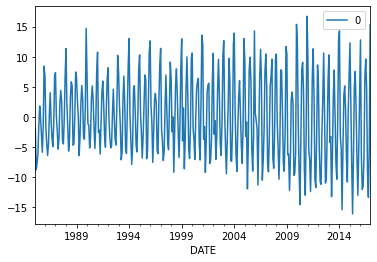

In [113]:
r.plot()

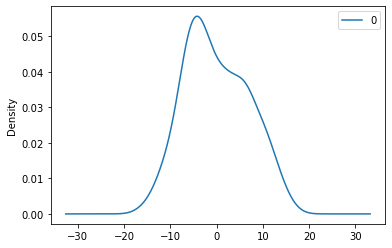

In [114]:
r.plot(kind="kde")